C:\Users\skdpa\AppData\Local\Temp\ipykernel_16924\3324087222.py:27: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\skdpa\AppData\Local\Temp\ipykernel_16924\3324087222.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


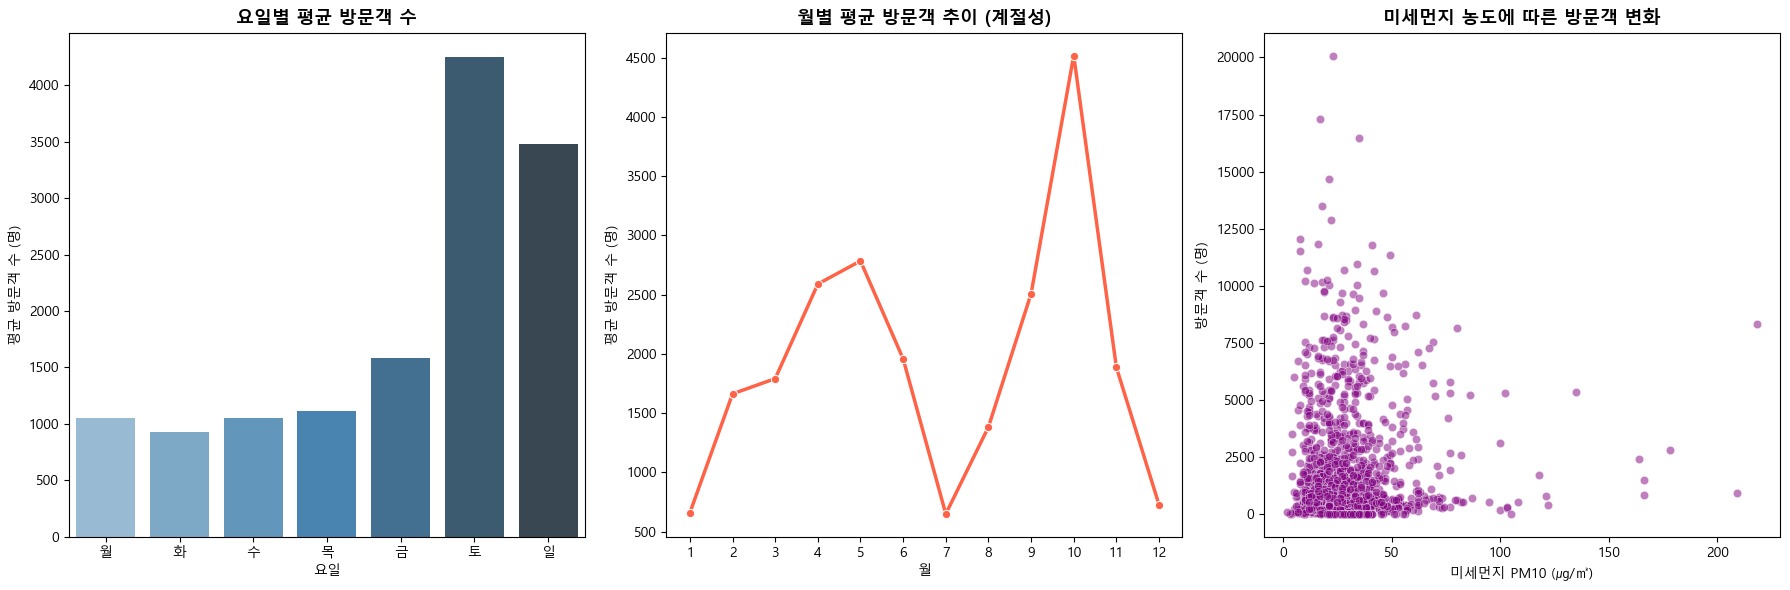

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (Windows 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 원본 df에서 날짜를 활용하기 위해 '월' 컬럼 추출 (시각화용)
df['월'] = df['일자'].dt.month

# 요일 이름을 한글로 변환하기 위한 매핑 (원핫 전처리 전이나 원본 기준)
# 요일 번호 (0:월, 1:화, 2:수, 3:목, 4:금, 5:토, 6:일)
def get_day_name(row):
    for i in range(7):
        if row[f'요일_{i}'] == 1:
            return ['월', '화', '수', '목', '금', '토', '일'][i]
from_df = df.copy()
from_df['요일이름'] = from_df.apply(get_day_name, axis=1)

# ==========================================
# 시각화 대시보드 형태 (3개 그래프 한 번에 보기)
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. 요일별 평균 방문객 수 (가장 직관적인 바 차트)
day_order = ['월', '화', '수', '목', '금', '토', '일']
sns.barplot(
    data=from_df, x='요일이름', y='전체건수', order=day_order, 
    palette='Blues_d', ax=axes[0], ci=None
)
axes[0].set_title('요일별 평균 방문객 수', fontsize=13, fontweight='bold')
axes[0].set_xlabel('요일')
axes[0].set_ylabel('평균 방문객 수 (명)')

# 2. 월별 평균 방문객 수 (계절성 트렌드 파악)
monthly_avg = from_df.groupby('월')['전체건수'].mean().reset_index()
sns.lineplot(
    data=monthly_avg, x='월', y='전체건수', 
    marker='o', color='tomato', linewidth=2.5, ax=axes[1]
)
axes[1].set_title('월별 평균 방문객 추이 (계절성)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('월')
axes[1].set_ylabel('평균 방문객 수 (명)')
axes[1].set_xticks(range(1, 13))

# 3. 미세먼지(PM10) 수준에 따른 방문객 산점도
sns.scatterplot(
    data=from_df, x='미세먼지_PM10', y='전체건수', 
    alpha=0.5, color='purple', ax=axes[2]
)
axes[2].set_title('미세먼지 농도에 따른 방문객 변화', fontsize=13, fontweight='bold')
axes[2].set_xlabel('미세먼지 PM10 (㎍/㎥)')
axes[2].set_ylabel('방문객 수 (명)')

plt.tight_layout()
plt.show()

C:\Users\skdpa\AppData\Local\Temp\ipykernel_16924\640435701.py:23: UserWarning: Glyph 127905 (\N{FERRIS WHEEL}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
c:\Users\skdpa\anaconda3\envs\data_analysis\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127905 (\N{FERRIS WHEEL}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


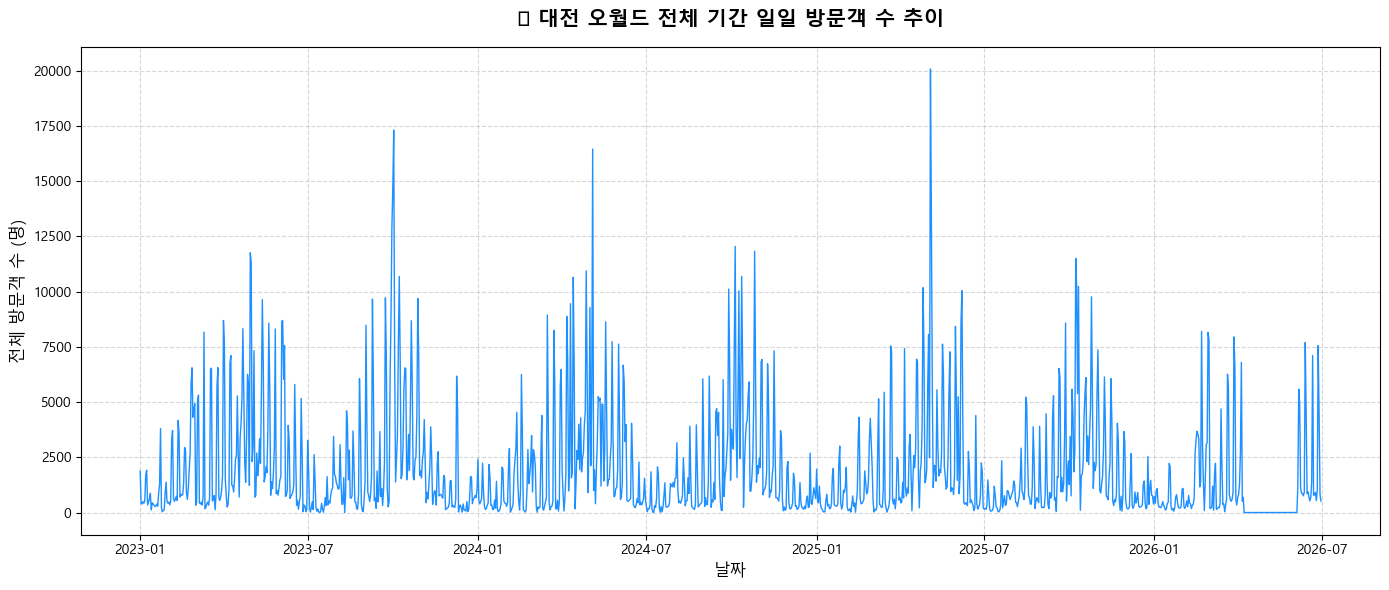

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (Windows 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 전체 날짜별 방문객 수 시각화 (라인 플롯)
# ==========================================
plt.figure(figsize=(14, 6))

# x축은 일자, y축은 전체건수
sns.lineplot(data=df, x='일자', y='전체건수', color='dodgerblue', linewidth=1)

plt.title('🎡 대전 오월드 전체 기간 일일 방문객 수 추이', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('날짜', fontsize=12)
plt.ylabel('전체 방문객 수 (명)', fontsize=12)

# 그리드(격자) 추가로 가독성 높이기
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. StandardScaler 객체 생성
scaler = StandardScaler()

# 2. 기상 변수들을 각각 '표준화(StandardScaler)' 적용
# (평균=0, 표준편차=1로 변환됩니다)
df_cleaned['기온_std'] = scaler.fit_transform(df_cleaned[['평균기온']])
df_cleaned['강수량_std'] = scaler.fit_transform(df_cleaned[['일강수량']])
df_cleaned['습도_std'] = scaler.fit_transform(df_cleaned[['평균상대습도']])

# 3. 표준화된 변수들을 활용한 '종합 날씨 점수' 산출
# - 기온과 습도는 높을수록 좋으므로 더하고,
# - 비(강수량)는 야외 활동에 방해가 되므로 빼줍니다 (-)
df_cleaned['날씨점수_std'] = (
    df_cleaned['기온_std'] 
    + df_cleaned['습도_std'] 
    - df_cleaned['강수량_std']
)

# 4. 전체 방문객 수('전체건수')와 새로 만든 '날씨점수_std' 간의 상관관계 계산
correlation = df_cleaned['날씨점수_std'].corr(df_cleaned['전체건수'])
print(f"🎯 표준화 기반 '날씨점수'와 '전체건수' 간의 상관계수: {correlation:.4f}")


# 5. 기존 개별 변수들의 표준화 값과 '전체건수' 간의 상관관계 비교
print("\n--- [전체건수와의 상관관계 비교 (표준화 기준)] ---")
comparison_cols = ['평균기온', '일강수량', '평균상대습도', '날씨점수_std', '전체건수']
# 원본 변수들과 표준화된 점수를 함께 비교해봅니다.
print(df_cleaned[['날씨점수_std', '전체건수']].corr())

🎯 새로 만든 '날씨점수'와 '전체건수' 간의 상관계수: 0.0706

--- [전체건수와의 상관관계 비교] ---
전체건수      1.000000
평균기온      0.137197
날씨점수      0.070575
평균상대습도   -0.083603
일강수량     -0.124660
Name: 전체건수, dtype: float64
